In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from IPython.display import display, clear_output

data_dir = '../../data/processed/'

X_train = pd.read_csv(f"{data_dir}X_train_v2.csv")
X_test = pd.read_csv(f"{data_dir}X_test_v2.csv")

y_train_raw = pd.read_csv(f"{data_dir}y_train_v2.csv")
y_test_raw = pd.read_csv(f"{data_dir}y_test_v2.csv")

y_train_clf = (y_train_raw > 0).astype(int)
y_test_clf = (y_test_raw > 0).astype(int)

print(y_train_clf.value_counts(normalize=True))
print(y_test_clf.value_counts(normalize=True))

area
1       0.520581
0       0.479419
Name: proportion, dtype: float64
area
1       0.528846
0       0.471154
Name: proportion, dtype: float64


In [3]:
def evaluate_classifier_family(family_name, models_dict, X_tr, y_tr, X_tst, y_tst):
    results = []
    confusion_matrices = {}
    
    y_tr_vals = y_tr.values.ravel()
    y_tst_vals = y_tst.values.ravel()
    
    for model_name, model_func in models_dict.items():
        try:
            model = model_func()
            model.fit(X_tr, y_tr_vals)
            
            preds = model.predict(X_tst)
            if hasattr(model, "predict_proba"):
                probas = model.predict_proba(X_tst)[:, 1]
            elif hasattr(model, "decision_function"):
                probas = model.decision_function(X_tst)
            else:
                probas = preds
                
            acc = accuracy_score(y_tst_vals, preds)
            prec = precision_score(y_tst_vals, preds, zero_division=0)
            rec = recall_score(y_tst_vals, preds, zero_division=0)
            f1 = f1_score(y_tst_vals, preds, zero_division=0)
            
            try:
                auc = roc_auc_score(y_tst_vals, probas)
            except:
                auc = 0.0
                
            cm = confusion_matrix(y_tst_vals, preds)
            confusion_matrices[model_name] = cm
            
            results.append({
                'Model': model_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1_Score': f1,
                'ROC_AUC': auc
            })
        except Exception as e:
            pass
            
    clear_output(wait=True)
    
    if results:
        df_results = pd.DataFrame(results)
        
        styled_df = df_results.style.format({
            'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 
            'Recall': '{:.4f}', 'F1_Score': '{:.4f}', 'ROC_AUC': '{:.4f}'
        }).set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1e1e1e'), ('color', '#00ffcc'), ('border', '1px solid #444'), ('text-align', 'center'), ('font-size', '14px'), ('padding', '8px')]},
            {'selector': 'td', 'props': [('background-color', '#2b2b2b'), ('color', '#f0f0f0'), ('border', '1px solid #444'), ('text-align', 'center'), ('font-size', '13px'), ('padding', '8px')]},
            {'selector': 'tr:hover td', 'props': [('background-color', '#3a3a3a'), ('color', '#ffffff')]}
        ])
        display(styled_df)
        
        n_models = len(confusion_matrices)
        n_cols = 3
        n_rows = int(np.ceil(n_models / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
        fig.patch.set_facecolor('#1e1e1e')
        axes = axes.flatten() if n_models > 1 else [axes]
        
        for idx, (m_name, cm) in enumerate(confusion_matrices.items()):
            ax = axes[idx]
            sns.heatmap(cm, annot=True, fmt='d', cmap='mako', ax=ax, 
                        cbar=False, annot_kws={"size": 14, "weight": "bold"})
            ax.set_title(m_name, color='white', fontsize=12, pad=10)
            ax.set_ylabel('Gerçek', color='#f0f0f0')
            ax.set_xlabel('Tahmin', color='#f0f0f0')
            ax.tick_params(colors='white')
            
        for idx in range(n_models, len(axes)):
            axes[idx].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
    return df_results

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.5673,0.5735,0.7091,0.6341,0.6130
1,KNN,0.5481,0.5667,0.6182,0.5913,0.5646
2,Random Forest,0.6538,0.6939,0.6182,0.6538,0.6917
3,SVC,0.5577,0.5542,0.8364,0.6667,0.5319
4,RVC,0.5481,0.5408,0.9636,0.6928,0.5978


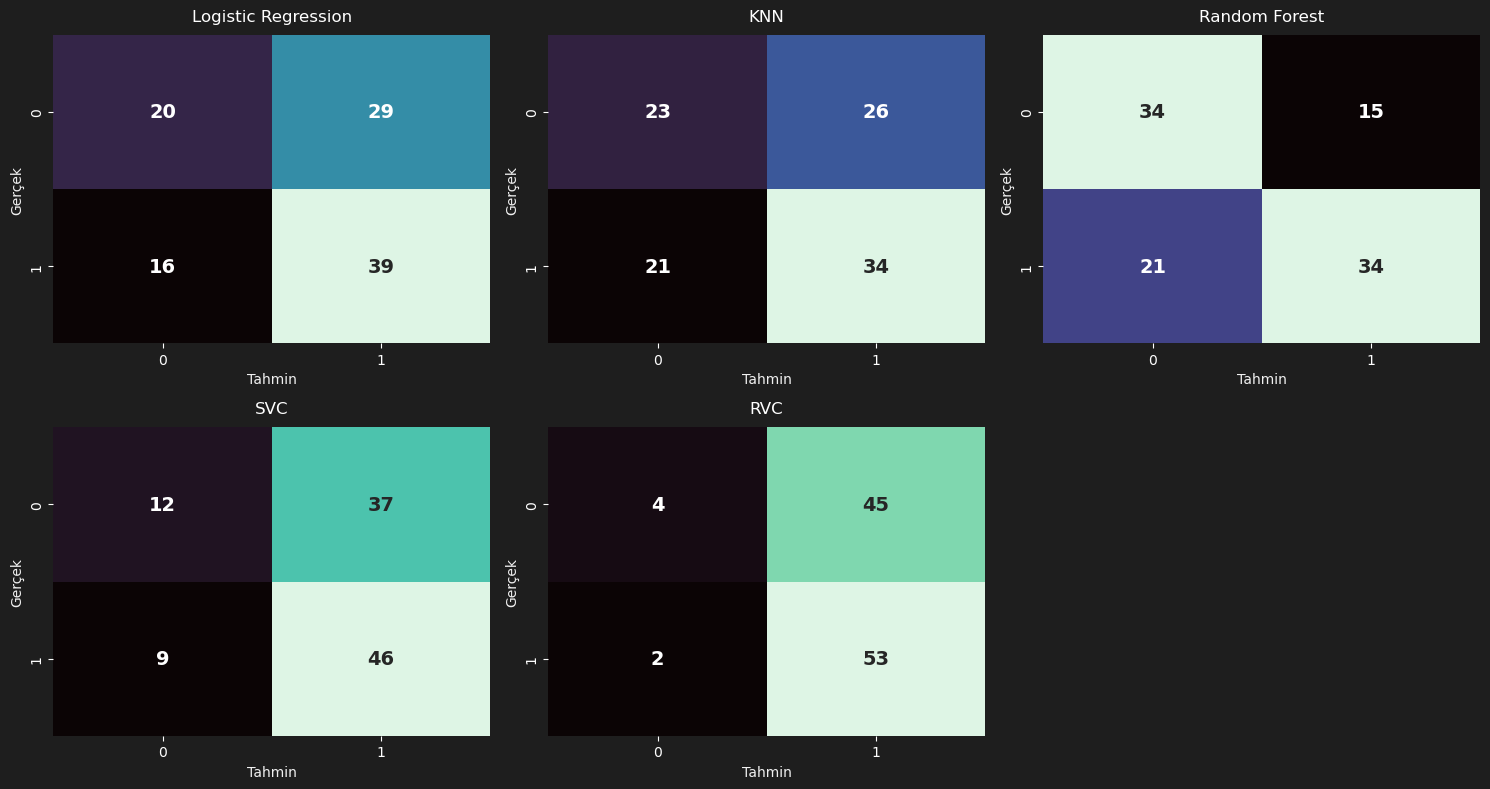

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from skrvm import RVC

stage1_clf_models = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000, random_state=42),
    'KNN': lambda: KNeighborsClassifier(n_neighbors=5),
    'Random Forest': lambda: RandomForestClassifier(n_estimators=200, random_state=42),
    'SVC': lambda: SVC(kernel='rbf', probability=True, random_state=42),
    'RVC': lambda: RVC(kernel='rbf')
}

stage1_clf_results = evaluate_classifier_family(
    family_name="Aşama 1: Klasik Modeller (Baseline)",
    models_dict=stage1_clf_models,
    X_tr=X_train,
    y_tr=y_train_clf,
    X_tst=X_test,
    y_tst=y_test_clf
)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,CatBoost,0.6250,0.6600,0.6000,0.6286,0.6675
1,ClassMLP (PyTorch Custom),0.5385,0.5507,0.6909,0.6129,0.5659
2,Yandex NODE,0.5385,0.5402,0.8545,0.6620,0.6071


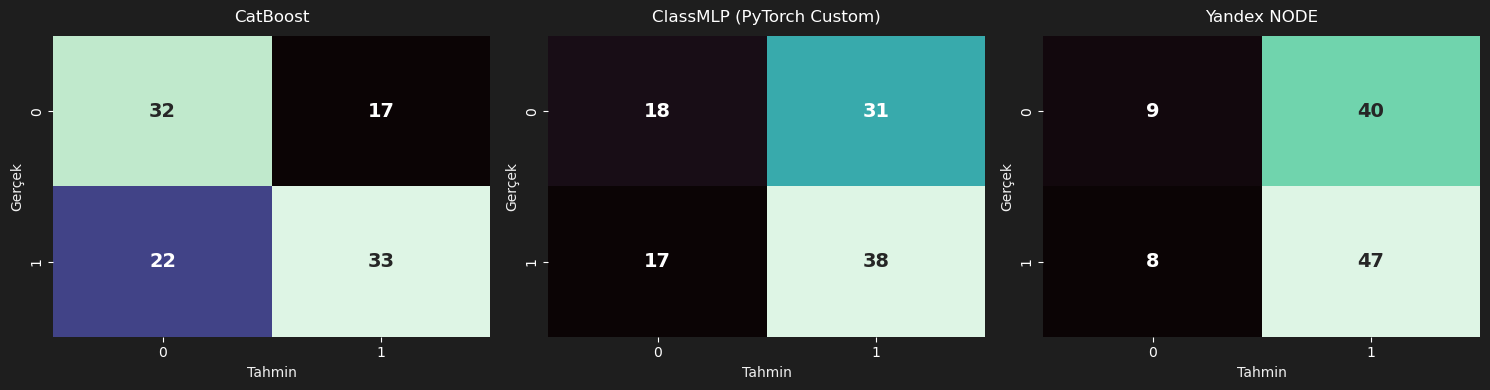

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.base import BaseEstimator, ClassifierMixin
from catboost import CatBoostClassifier

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("pytorch_tabular").setLevel(logging.ERROR)

from pytorch_tabular import TabularModel
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig

class MLPNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, regularize=False):
        super().__init__()
        if not regularize:
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim//2), nn.ReLU(),
                nn.Linear(hidden_dim//2, 1)
            )
        else:
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(hidden_dim, hidden_dim//2), nn.BatchNorm1d(hidden_dim//2), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(hidden_dim//2, 1)
            )
    def forward(self, x):
        return self.net(x)

class ClassMLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_dim=64, regularize=False, epochs=150, lr=1e-3):
        self.hidden_dim = hidden_dim
        self.regularize = regularize
        self.epochs = epochs
        self.lr = lr
        self.model = None

    def fit(self, X, y):
        X_t = torch.tensor(X if not hasattr(X, 'values') else X.values, dtype=torch.float32)
        y_t = torch.tensor(y if not hasattr(y, 'values') else y.values, dtype=torch.float32).view(-1, 1)
        
        self.model = MLPNet(input_dim=X_t.shape[1], hidden_dim=self.hidden_dim, regularize=self.regularize)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        
        self.model.train()
        for epoch in range(self.epochs):
            optimizer.zero_grad()
            preds = self.model(X_t)
            loss = criterion(preds, y_t)
            loss.backward()
            optimizer.step()
        return self

    def predict_proba(self, X):
        self.model.eval()
        X_t = torch.tensor(X if not hasattr(X, 'values') else X.values, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_t)
            probs = torch.sigmoid(logits).numpy()
            return np.hstack((1 - probs, probs))
            
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

class PyTorchTabularClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model_name='node', epochs=15, learning_rate=1e-3, batch_size=64):
        self.model_name = model_name
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.model = None

    def fit(self, X, y):
        df_train = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        df_train.columns = [f"f_{i}" for i in range(df_train.shape[1])]
        num_cols = list(df_train.columns)
        
        target_name = 'target_y'
        df_train[target_name] = y if not isinstance(y, pd.Series) else y.values
        df_train[target_name] = df_train[target_name].astype(str)

        data_config = DataConfig(target=[target_name], continuous_cols=num_cols, categorical_cols=[])
        
        trainer_config = TrainerConfig(
            auto_lr_find=False,
            batch_size=self.batch_size,
            max_epochs=self.epochs,
            early_stopping="valid_loss",
            early_stopping_patience=3,
            checkpoints="valid_loss",
            progress_bar="none",
            trainer_kwargs={"enable_model_summary": False}
        )
        optimizer_config = OptimizerConfig()
        
        from pytorch_tabular.models import NodeConfig
        model_config = NodeConfig(task="classification", learning_rate=self.learning_rate)
        
        self.model = TabularModel(
            data_config=data_config,
            model_config=model_config,
            optimizer_config=optimizer_config,
            trainer_config=trainer_config,
            verbose=False,
            suppress_lightning_logger=True
        )
        self.model.fit(train=df_train)
        return self

    def predict_proba(self, X):
        df_test = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        df_test.columns = [f"f_{i}" for i in range(df_test.shape[1])]
        preds = self.model.predict(df_test, include_input_features=False)
        
        prob_cols = [c for c in preds.columns if 'probability' in c]
        if len(prob_cols) >= 2:
            return preds[prob_cols].values
        elif len(prob_cols) == 1:
            probs = preds[prob_cols[0]].values
            return np.vstack((1 - probs, probs)).T
        else:
            preds_class = preds.iloc[:, -1].astype(int).values
            probs = np.zeros((len(preds_class), 2))
            probs[np.arange(len(preds_class)), preds_class] = 1.0
            return probs
            
    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

stage2_clf_models = {
    'CatBoost': lambda: CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05, verbose=0, random_seed=42),
    'ClassMLP (PyTorch Custom)': lambda: ClassMLPWrapper(regularize=True),
    'Yandex NODE': lambda: PyTorchTabularClassifierWrapper(model_name='node')
}

stage2_clf_results = evaluate_classifier_family(
    family_name="Aşama 2: Modern Şampiyonlar (Deep & Boosting)",
    models_dict=stage2_clf_models,
    X_tr=X_train,
    y_tr=y_train_clf,
    X_tst=X_test,
    y_tst=y_test_clf
)

Hücre 5: Tüm Modeller için Karşılaştırmalı Eğriler çiziliyor...


2026-07-24 20:53:47,287 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


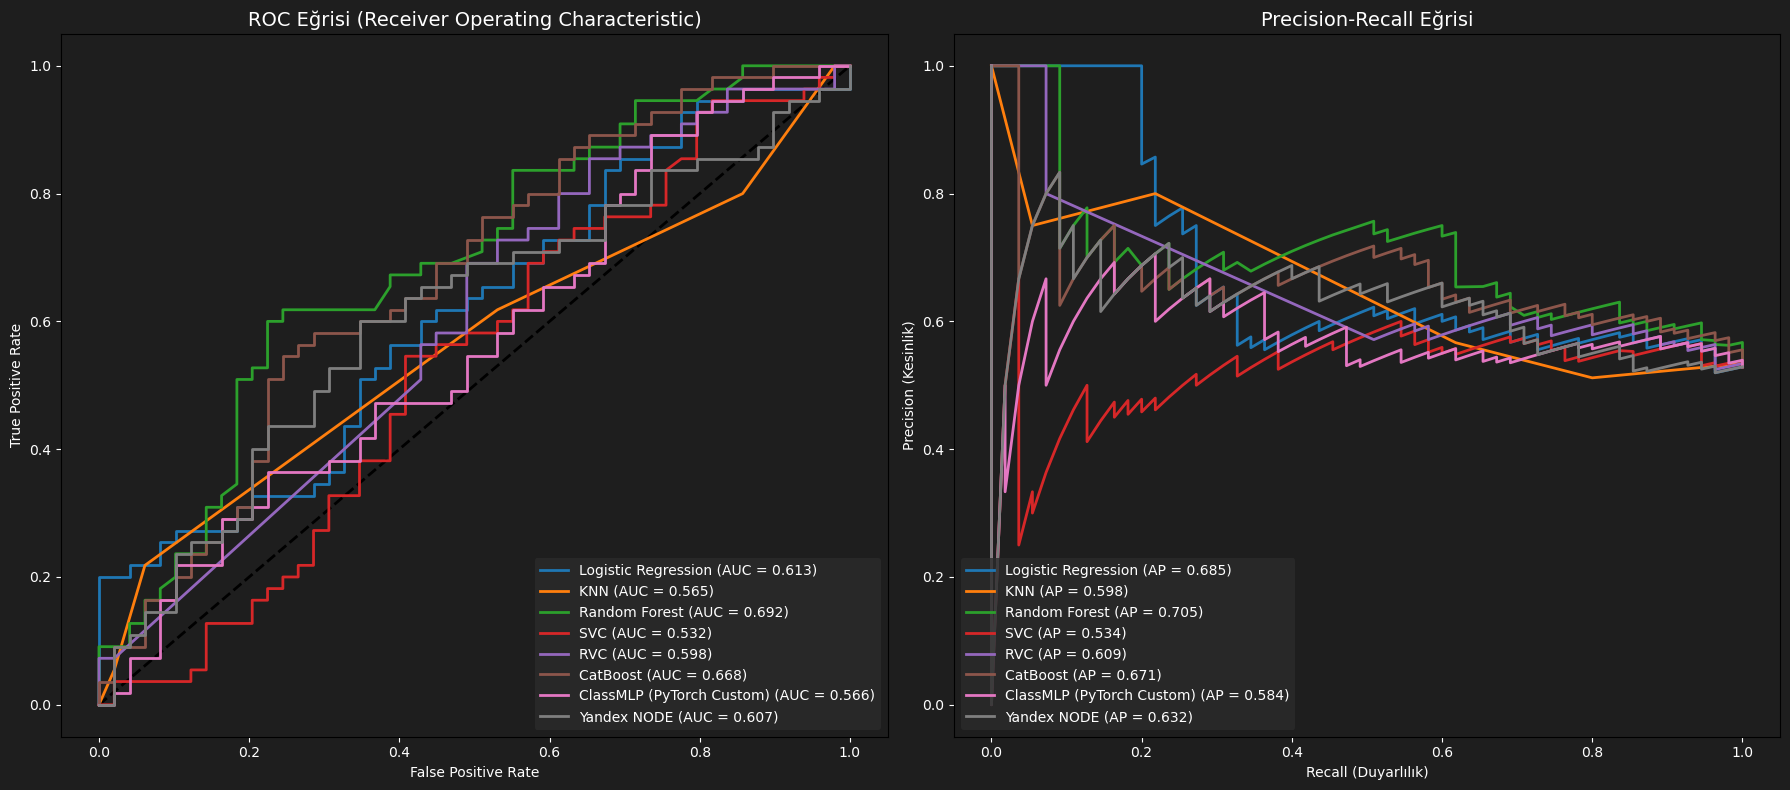

In [11]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

all_models = {**stage1_clf_models, **stage2_clf_models}

def plot_comparative_curves(models_dict, X_tr, y_tr, X_tst, y_tst):
    y_tr_vals = y_tr.values.ravel()
    y_tst_vals = y_tst.values.ravel()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    fig.patch.set_facecolor('#1e1e1e')
    
    ax1.set_facecolor('#1e1e1e')
    ax2.set_facecolor('#1e1e1e')
    
    ax1.plot([0, 1], [0, 1], 'k--', lw=2)
    
    for model_name, model_func in models_dict.items():
        try:
            model = model_func()
            model.fit(X_tr, y_tr_vals)
            
            if hasattr(model, "predict_proba"):
                probas = model.predict_proba(X_tst)[:, 1]
            elif hasattr(model, "decision_function"):
                probas = model.decision_function(X_tst)
                probas = (probas - probas.min()) / (probas.max() - probas.min())
            else:
                continue
                
            fpr, tpr, _ = roc_curve(y_tst_vals, probas)
            roc_auc = auc(fpr, tpr)
            ax1.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.3f})")
            
            precision, recall, _ = precision_recall_curve(y_tst_vals, probas)
            pr_auc = average_precision_score(y_tst_vals, probas)
            ax2.plot(recall, precision, lw=2, label=f"{model_name} (AP = {pr_auc:.3f})")
            
        except Exception as e:
            pass
            
    ax1.set_title("ROC Eğrisi (Receiver Operating Characteristic)", color='white', fontsize=14)
    ax1.set_xlabel("False Positive Rate", color='white')
    ax1.set_ylabel("True Positive Rate", color='white')
    ax1.tick_params(colors='white')
    ax1.legend(loc='lower right', facecolor='#2b2b2b', edgecolor='none', labelcolor='white')
    
    ax2.set_title("Precision-Recall Eğrisi", color='white', fontsize=14)
    ax2.set_xlabel("Recall (Duyarlılık)", color='white')
    ax2.set_ylabel("Precision (Kesinlik)", color='white')
    ax2.tick_params(colors='white')
    ax2.legend(loc='lower left', facecolor='#2b2b2b', edgecolor='none', labelcolor='white')
    
    plt.tight_layout()
    plt.show()

print("Hücre 5: Tüm Modeller için Karşılaştırmalı Eğriler çiziliyor...")
plot_comparative_curves(all_models, X_train, y_train_clf, X_test, y_test_clf)

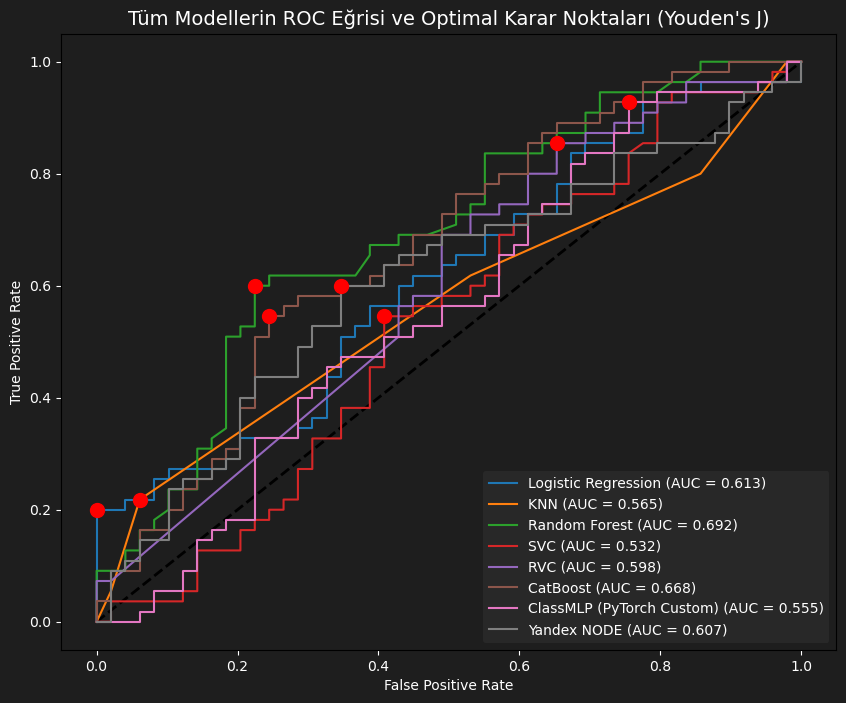

,Model,Default_Acc,Optimal_Acc,Default_F1,Optimal_F1,Opt_Threshold,ROC_AUC,Acc_Farkı
0,Logistic Regression,0.5673,0.5769,0.6341,0.3333,0.6143,0.6130,+0.0096
1,KNN,0.5481,0.5577,0.5913,0.3429,0.8000,0.5646,+0.0096
2,Random Forest,0.6346,0.6827,0.6415,0.6667,0.5375,0.6917,+0.0481
3,SVC,0.5577,0.5673,0.6714,0.5714,0.5406,0.5319,+0.0096
4,RVC,0.5481,0.6154,0.6928,0.7015,0.6359,0.5978,+0.0673
5,CatBoost,0.6250,0.6442,0.6286,0.6186,0.5904,0.6675,+0.0192
6,ClassMLP (PyTorch Custom),0.5577,0.6058,0.6462,0.7133,0.4675,0.5555,+0.0481
7,Yandex NODE,0.5385,0.6250,0.6620,0.6286,0.5014,0.6071,+0.0865


In [12]:
def evaluate_optimal_thresholds(models_dict, X_tr, y_tr, X_tst, y_tst):
    y_tr_vals = y_tr.values.ravel()
    y_tst_vals = y_tst.values.ravel()
    
    results = []
    
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', lw=2) 
    
    for model_name, model_func in models_dict.items():
        print(f"-> {model_name} için Optimal Eşik aranıyor...")
        try:
            model = model_func()
            model.fit(X_tr, y_tr_vals)
            
            if hasattr(model, "predict_proba"):
                probas = model.predict_proba(X_tst)[:, 1]
            elif hasattr(model, "decision_function"):
                probas = model.decision_function(X_tst)
                probas = (probas - probas.min()) / (probas.max() - probas.min())
            else:
                continue
                
            fpr, tpr, thresholds = roc_curve(y_tst_vals, probas)
            
            j_scores = tpr - fpr
            optimal_idx = np.argmax(j_scores)
            optimal_threshold = thresholds[optimal_idx]
            
            preds_default = (probas >= 0.5).astype(int)
            preds_optimal = (probas >= optimal_threshold).astype(int)
            
            acc_default = accuracy_score(y_tst_vals, preds_default)
            acc_optimal = accuracy_score(y_tst_vals, preds_optimal)
            
            f1_default = f1_score(y_tst_vals, preds_default, zero_division=0)
            f1_optimal = f1_score(y_tst_vals, preds_optimal, zero_division=0)
            
            auc_val = auc(fpr, tpr)
            
            results.append({
                'Model': model_name,
                'Default_Acc': acc_default,
                'Optimal_Acc': acc_optimal,
                'Default_F1': f1_default,
                'Optimal_F1': f1_optimal,
                'Opt_Threshold': optimal_threshold,
                'ROC_AUC': auc_val
            })
            
            plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_val:.3f})")
            plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100, zorder=5)
            
        except Exception as e:
            pass
            
    clear_output(wait=True)
    plt.title("Tüm Modellerin ROC Eğrisi ve Optimal Karar Noktaları (Youden's J)", color='white', fontsize=14)
    plt.xlabel("False Positive Rate", color='white')
    plt.ylabel("True Positive Rate", color='white')
    plt.legend(loc='lower right', facecolor='#2b2b2b', edgecolor='none', labelcolor='white')
    plt.tick_params(colors='white')
    plt.gcf().patch.set_facecolor('#1e1e1e')
    plt.gca().set_facecolor('#1e1e1e')
    plt.show()
    
    if results:
        df_results = pd.DataFrame(results)
        df_results['Acc_Farkı'] = df_results['Optimal_Acc'] - df_results['Default_Acc']
        
        styled_df = df_results.style.format({
            'Default_Acc': '{:.4f}', 'Optimal_Acc': '{:.4f}', 
            'Default_F1': '{:.4f}', 'Optimal_F1': '{:.4f}',
            'Opt_Threshold': '{:.4f}', 'Acc_Farkı': '{:+.4f}', 'ROC_AUC': '{:.4f}'
        }).set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1e1e1e'), ('color', '#00ffcc'), ('border', '1px solid #444'), ('text-align', 'center'), ('font-size', '14px'), ('padding', '8px')]},
            {'selector': 'td', 'props': [('background-color', '#2b2b2b'), ('color', '#f0f0f0'), ('border', '1px solid #444'), ('text-align', 'center'), ('font-size', '13px'), ('padding', '8px')]},
            {'selector': 'tr:hover td', 'props': [('background-color', '#3a3a3a'), ('color', '#ffffff')]}
        ])
        
        def highlight_diff(val):
            try:
                v = float(val)
                color = '#00ff00' if v > 0 else '#ff3333' if v < 0 else 'gray'
                return f'color: {color}; font-weight: bold;'
            except:
                return ''
                
        try:
            display(styled_df.applymap(highlight_diff, subset=['Acc_Farkı']))
        except:
            display(styled_df.map(highlight_diff, subset=['Acc_Farkı']))

print("Hücre 6: Tüm 8 modelin Optimal Threshold hesabı başlıyor...")
evaluate_optimal_thresholds(all_models, X_train, y_train_clf, X_test, y_test_clf)

In [13]:
import optuna
from sklearn.model_selection import cross_val_score
import time

optuna.logging.set_verbosity(optuna.logging.WARNING)

def optimize_champions_f1(X_tr, y_tr):
    y_tr_vals = y_tr.values.ravel()
    
    def objective_rf(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
            'random_state': 42
        }
        model = RandomForestClassifier(**params)
        score = cross_val_score(model, X_tr, y_tr_vals, cv=5, scoring='f1').mean()
        return score

    def objective_mlp(trial):
        params = {
            'hidden_dim': trial.suggest_categorical('hidden_dim', [32, 64, 128]),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'epochs': trial.suggest_int('epochs', 50, 200),
            'regularize': trial.suggest_categorical('regularize', [True, False])
        }
        model = ClassMLPWrapper(**params)
        score = cross_val_score(model, X_tr, y_tr_vals, cv=5, scoring='f1').mean()
        return score

    def objective_node(trial):
        params = {
            'model_name': 'node',
            'epochs': trial.suggest_int('epochs', 10, 30),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128])
        }
        model = PyTorchTabularClassifierWrapper(**params)
        score = cross_val_score(model, X_tr, y_tr_vals, cv=5, scoring='f1').mean()
        return score

    print("--- F1-SCORE ODAKLI OPTUNA LABORATUVARI BAŞLIYOR ---")
    
    # RANDOM FOREST
    print("\n1. Random Forest (F1 Hedefli) Optimize Ediliyor... (50 Deneme)")
    start_time = time.time()
    study_rf = optuna.create_study(direction='maximize')
    study_rf.optimize(objective_rf, n_trials=50, n_jobs=-1)
    print(f"Bitti! Süre: {time.time() - start_time:.2f} saniye")
    print(f"-> RF En İyi CV Skoru (F1): {study_rf.best_value:.4f}")
    
    # CLASSMLP
    print("\n2. ClassMLP (F1 Hedefli) Optimize Ediliyor... (20 Deneme)")
    start_time = time.time()
    study_mlp = optuna.create_study(direction='maximize')
    study_mlp.optimize(objective_mlp, n_trials=20, n_jobs=1)
    print(f"Bitti! Süre: {time.time() - start_time:.2f} saniye")
    print(f"-> ClassMLP En İyi CV Skoru (F1): {study_mlp.best_value:.4f}")
    
    # YANDEX NODE
    print("\n3. Yandex NODE (F1 Hedefli) Optimize Ediliyor... (15 Deneme)")
    start_time = time.time()
    study_node = optuna.create_study(direction='maximize')
    study_node.optimize(objective_node, n_trials=15, n_jobs=1)
    print(f"Bitti! Süre: {time.time() - start_time:.2f} saniye")
    print(f"-> Yandex NODE En İyi CV Skoru (F1): {study_node.best_value:.4f}")

    return study_rf, study_mlp, study_node

study_rf, study_mlp, study_node = optimize_champions_f1(X_train, y_train_clf)

--- F1-SCORE ODAKLI OPTUNA LABORATUVARI BAŞLIYOR ---

1. Random Forest (F1 Hedefli) Optimize Ediliyor... (50 Deneme)
Bitti! Süre: 60.49 saniye
-> RF En İyi CV Skoru (F1): 0.6331

2. ClassMLP (F1 Hedefli) Optimize Ediliyor... (20 Deneme)


2026-07-24 21:06:19,497 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....


Bitti! Süre: 16.31 saniye
-> ClassMLP En İyi CV Skoru (F1): 0.5807

3. Yandex NODE (F1 Hedefli) Optimize Ediliyor... (15 Deneme)


c:\Users\Asus\anaconda3\envs\ai_proje\lib\site-packages\pytorch_tabular\tabular_model.py:1467: DeprecationWarning: `include_input_features` will be deprecated in the next release. Please add index columns to the test dataframe if you want to retain some features like the key or id
  warnings.warn(
c:\Users\Asus\anaconda3\envs\ai_proje\lib\site-packages\pytorch_tabular\tabular_model.py:1316: DeprecationWarning: Classification prediction column will be renamed to `{target_col}_prediction` in the next release to maintain consistency with regression.
  warnings.warn(
2026-07-24 21:06:23,650 - {pytorch_tabular.models.node.node_model:74} - INFO - Data Aware Initialization of NODE using a forward pass with 2000 batch size....
c:\Users\Asus\anaconda3\envs\ai_proje\lib\site-packages\pytorch_tabular\tabular_model.py:1467: DeprecationWarning: `include_input_features` will be deprecated in the next release. Please add index columns to the test dataframe if you want to retain some features like the

Bitti! Süre: 284.60 saniye
-> Yandex NODE En İyi CV Skoru (F1): 0.6855


c:\Users\Asus\anaconda3\envs\ai_proje\lib\site-packages\pytorch_tabular\tabular_model.py:1467: DeprecationWarning: `include_input_features` will be deprecated in the next release. Please add index columns to the test dataframe if you want to retain some features like the key or id
  warnings.warn(
c:\Users\Asus\anaconda3\envs\ai_proje\lib\site-packages\pytorch_tabular\tabular_model.py:1316: DeprecationWarning: Classification prediction column will be renamed to `{target_col}_prediction` in the next release to maintain consistency with regression.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Random Forest (F1-Opt),0.6442,0.6250,0.8182,0.7087,0.6801
1,ClassMLP (F1-Opt),0.5288,0.6250,0.2727,0.3797,0.5521
2,Yandex NODE (F1-Opt),0.5192,0.5253,0.9455,0.6753,0.5829


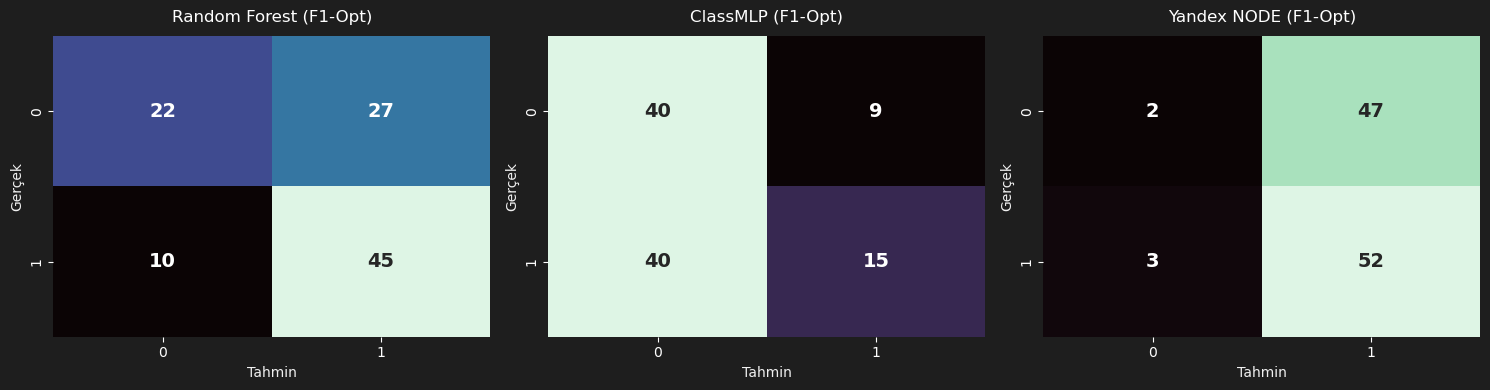

In [14]:
final_models = {
    'Random Forest (F1-Opt)': lambda: RandomForestClassifier(**study_rf.best_params),
    'ClassMLP (F1-Opt)': lambda: ClassMLPWrapper(**study_mlp.best_params),
    'Yandex NODE (F1-Opt)': lambda: PyTorchTabularClassifierWrapper(**{**study_node.best_params, 'model_name': 'node'})
}

final_results = evaluate_classifier_family(
    family_name="F1 Optimizasyonu Sonrası Şampiyonlar Ligi",
    models_dict=final_models,
    X_tr=X_train,
    y_tr=y_train_clf,
    X_tst=X_test,
    y_tst=y_test_clf
)